In [2]:
import pandas as pd

# Load data awal
file_path = '97ca96d3-e858-4d82-bcc1-c7a5d86376f0.csv'
df = pd.read_csv(file_path, sep=';', encoding='cp1252')

print("File Berhasil Dimuat.")

File Berhasil Dimuat.


In [3]:
#DATA CLEANING - HARGA
def clean_harga(x):
    if pd.isna(x) or str(x).strip() == "":
        return 0

    # 1. Hapus Rp dan titik ribuan
    teks = str(x).replace('Rp', '').replace('.', '').strip()

    # 2. Tangani rentang harga (misal: '15899 - 16920')
    if '-' in teks:
        # Ambil angka pertama saja sebelum tanda hubung
        teks = teks.split('-')[0].strip()

    try:
        return int(teks)
    except:
        return 0

# Proses Cleaning
df['harga_clean'] = df['harga'].apply(clean_harga)

print("PERBANDINGAN KOLOM HARGA (Setelah Perbaikan Rentang):")
print(df[['harga', 'harga_clean']].iloc[:10]) # Cek baris lain juga

PERBANDINGAN KOLOM HARGA (Setelah Perbaikan Rentang):
                 harga  harga_clean
0             Rp52.200        52200
1             Rp59.000        59000
2            Rp178.200       178200
3             Rp32.900        32900
4             Rp49.476        49476
5             Rp79.000        79000
6             Rp35.474        35474
7  Rp15.899 - Rp16.920        15899
8             Rp68.400        68400
9             Rp43.500        43500


In [4]:
#DATA CLEANING - HARGA AWAL (harga_coret)
df['harga_coret_clean'] = df['harga_coret'].apply(clean_harga)

# Jika harga_coret_clean 0 (kosong), isi dengan harga_clean
df.loc[df['harga_coret_clean'] == 0, 'harga_coret_clean'] = df['harga_clean']

print("PERBANDINGAN KOLOM HARGA CORET:")
print(df[['harga_coret', 'harga_coret_clean']].head(10))

PERBANDINGAN KOLOM HARGA CORET:
  harga_coret  harga_coret_clean
0   Rp180.000             180000
1   Rp200.000             200000
2   Rp229.000             229000
3    Rp60.000              60000
4    Rp79.800              79800
5   Rp158.000             158000
6    Rp80.000              80000
7    Rp36.000              36000
8   Rp180.000             180000
9   Rp199.000             199000


In [5]:
#DATA CLEANING - JUMLAH TERJUAL
def clean_terjual(x):
    if pd.isna(x) or str(x).strip() == "": return 0
    teks = str(x).upper().replace('+', '').replace('.', '').replace(' ', '').strip()
    if 'RB' in teks:
        teks = teks.replace('RB', '').replace(',', '.')
        return int(float(teks) * 1000)
    return int(teks)

# Proses Cleaning
df['terjual_clean'] = df['terjual'].apply(clean_terjual)

print("PERBANDINGAN KOLOM TERJUAL:")
print(df[['terjual', 'terjual_clean']].head(10))

PERBANDINGAN KOLOM TERJUAL:
  terjual  terjual_clean
0      57             57
1      18             18
2     164            164
3      77             77
4     203            203
5    8RB+           8000
6     366            366
7    2RB+           2000
8      80             80
9      27             27


In [6]:
# #DATA CLEANING - RATING

def clean_rating(x):
    if pd.isna(x) or str(x).strip() == "":
        return 0.0
    # Ubah koma menjadi titik agar dibaca sebagai desimal (float)
    teks = str(x).replace(',', '.')
    try:
        return float(teks)
    except:
        return 0.0

# Proses Cleaning
df['rating_clean'] = df['rating'].apply(clean_rating)

print("PERBANDINGAN KOLOM RATING:")
print(df[['rating', 'rating_clean']].head(10))

PERBANDINGAN KOLOM RATING:
  rating  rating_clean
0    5.0           5.0
1    4,9           4.9
2    4.9           4.9
3      5           5.0
4    4.9           4.9
5    4.9           4.9
6    4.9           4.9
7    4.9           4.9
8    4.7           4.7
9    4.8           4.8


In [7]:
# DATA CLEANING - JUMLAH RATING
def clean_jumlah_rating(x):
    # 1. Cek jika kosong atau NaN
    if pd.isna(x) or str(x).strip() == "":
        return 0

    # 2. Standarisasi teks: huruf besar, hapus '+', hapus titik ribuan, hapus spasi
    teks = str(x).upper().replace('+', '').replace('.', '').replace(' ', '').strip()

    # 3. Tangani format "RB" (Ribu)
    if 'RB' in teks:
        # Ganti koma dengan titik untuk konversi float, hapus 'RB'
        teks = teks.replace('RB', '').replace(',', '.')
        try:
            # Ubah ke float dulu, kali 1000, lalu bulatkan ke int
            return int(float(teks) * 1000)
        except:
            return 0

    # 4. Tangani angka biasa (mungkin masih ada koma desimal tapi tanpa 'RB')
    try:
        # Gunakan float() dulu agar aman jika ada karakter '.' atau ',' yang tersisa
        return int(float(teks.replace(',', '.')))
    except:
        return 0

# Proses Cleaning
df['jumlah_rating_clean'] = df['jumlah_rating'].apply(clean_jumlah_rating)

print("PERBANDINGAN KOLOM JUMLAH RATING:")
print(df[['jumlah_rating', 'jumlah_rating_clean']].head(10))

PERBANDINGAN KOLOM JUMLAH RATING:
  jumlah_rating  jumlah_rating_clean
0            20                   20
1             7                    7
2            85                   85
3            18                   18
4            69                   69
5         2,8RB                 2800
6           104                  104
7           964                  964
8            25                   25
9             4                    4


Missing Value Handling untuk kolom numerik dan text

cek duplikasi dulu semua kolom

In [8]:
# --- CEK DUPLIKASI ---
# Mengecek duplikasi pada seluruh kolom (baris yang identik persis)
duplicate_count = df.duplicated().sum()

if duplicate_count > 0:
    print(f"Terdapat {duplicate_count} data duplikasi ditemukan.")
    # Opsional: Menampilkan beberapa contoh data yang duplikat
    # print(df[df.duplicated(keep=False)].head(5))

    # Menghapus duplikasi dan mereset index agar rapi kembali
    df = df.drop_duplicates().reset_index(drop=True)
    print("✅ Data duplikasi telah dihapus.")
else:
    print("Tidak ada duplikasi ditemukan. Data kamu sudah unik!")

print("-" * 30)
# Tampilkan info dataset setelah pembersihan
print(f"Jumlah baris saat ini: {len(df)}")

Tidak ada duplikasi ditemukan. Data kamu sudah unik!
------------------------------
Jumlah baris saat ini: 1000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   1000 non-null   object 
 1   url                  1000 non-null   object 
 2   product_name         1000 non-null   object 
 3   rating               986 non-null    object 
 4   jumlah_rating        986 non-null    object 
 5   terjual              1000 non-null   object 
 6   harga                1000 non-null   object 
 7   harga_coret          909 non-null    object 
 8   desc                 980 non-null    object 
 9   jumlah_foto          1000 non-null   int64  
 10  search_tab           1000 non-null   object 
 11  harga_clean          1000 non-null   int64  
 12  harga_coret_clean    1000 non-null   int64  
 13  terjual_clean        1000 non-null   int64  
 14  rating_clean         1000 non-null   float64
 15  jumlah_rating_clean  1000 non-null   in

In [10]:
# --- CEK KEBERADAAN KOLOM SEBELUM IMPUTASI ---
print("Daftar kolom yang ada di data saat ini:", df.columns.tolist())
print("-" * 30)

# IMPUTASI KOLOM NUMERIK
kolom_numerik = [
    'harga_clean',
    'terjual_clean',
    'rating_clean',
    'jumlah_rating_clean',
]

# Hitung jumlah missing value (NaN) per kolom dengan proteksi Error
for col in kolom_numerik:
    if col in df.columns:
        jumlah_kosong = df[col].isnull().sum()
        print(f" Kolom {col}: {jumlah_kosong} baris kosong")
    else:
        print(f"ERROR: Kolom '{col}' TIDAK DITEMUKAN! Pastikan sel cleaning sudah dijalankan.")

# Jika kamu ingin mengisi data kosong (Imputasi) dengan Median:
for col in kolom_numerik:
    if col in df.columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

print("-" * 30)
print("Proses Imputasi Selesai.")

Daftar kolom yang ada di data saat ini: ['id', 'url', 'product_name', 'rating', 'jumlah_rating', 'terjual', 'harga', 'harga_coret', 'desc', 'jumlah_foto', 'search_tab', 'harga_clean', 'harga_coret_clean', 'terjual_clean', 'rating_clean', 'jumlah_rating_clean']
------------------------------
 Kolom harga_clean: 0 baris kosong
 Kolom terjual_clean: 0 baris kosong
 Kolom rating_clean: 0 baris kosong
 Kolom jumlah_rating_clean: 0 baris kosong
------------------------------
Proses Imputasi Selesai.


In [11]:
# IMPUTASI KOLOM NUMERIK

kolom_numerik = [
    'harga_clean',
    'terjual_clean',
    'rating_clean',
    'jumlah_rating_clean',

]

#Hitung jumlah missing value (NaN) per kolom
for col in kolom_numerik:
    jumlah_kosong = df[col].isnull().sum()
    print(f"- Kolom {col}: {jumlah_kosong} baris kosong")

- Kolom harga_clean: 0 baris kosong
- Kolom terjual_clean: 0 baris kosong
- Kolom rating_clean: 0 baris kosong
- Kolom jumlah_rating_clean: 0 baris kosong


In [12]:
#IMPUTASI KOLOM TEXT


# 1. Cek Produk Name
df_name_kosong = df[df['product_name'].isnull() | (df['product_name'].astype(str).str.strip() == "")]

if not df_name_kosong.empty:
    # Tampilkan index dan kolom pendukung untuk identifikasi
    print(df_name_kosong[['product_name', 'search_tab', 'harga_clean']])
    print(f"\nTotal ditemukan: {len(df_name_kosong)} baris dengan nama produk kosong.")
else:
    print("Product_name tidak memiliki baris kosong.")

Product_name tidak memiliki baris kosong.


In [13]:
# 2. Cek Kolom Desc
df_desc_kosong = df[df['desc'].isnull() | (df['desc'].astype(str).str.strip() == "")]

if not df_desc_kosong.empty:
    # Kita tampilkan nama produknya juga supaya kamu tahu produk apa yang deskripsinya kosong
    print(df_desc_kosong[['product_name', 'desc', 'search_tab']].head(10))
    print(f"\nTotal ditemukan {len(df_desc_kosong)} baris kosong.")
else:
    print("kolom deskripsi (desc) tidak memiliki baris kosong.")

                                          product_name desc search_tab
15   Premium Kartun Lucu Kupu-Kupu Ribbon Casing HP...  NaN    Terbaru
24   Myroots Crystal Frost Case Untuk iPhone 16 15 ...  NaN    Terbaru
33   Case Melted Liquid Chocolate Design 3D Silicon...  NaN    Terbaru
35   Case Magsafe BLACK MATTE + PACKING BOX Premium...  NaN    Terbaru
54   BIU BIU CASE Jelly Color 2 in 1 Case - Compati...  NaN    Terbaru
89   KODAD Case iphone magsafe 11/12/13/14/15/16/17...  NaN    Terbaru
92   Premium Kartun Cry Baby Casing HP Untuk iPhone...  NaN    Terbaru
203  With Lanyard Clear Case For iPhone 17 Pro Max ...  NaN    Terbaru
211  case iPhone 13 Casing ponsel berbahan kulit Ko...  NaN    Terbaru
213  Case Matte Magsafe for iPhone 11 12 13 14 15 1...  NaN    Terbaru

Total ditemukan 20 baris kosong.


In [14]:
# 3. Cek Kolom Search_Tab
df_search_kosong = df[df['search_tab'].isnull() | (df['search_tab'].astype(str).str.strip() == "")]

if not df_search_kosong.empty:
    # Tampilkan beberapa baris untuk melihat polanya
    print(df_search_kosong[['product_name', 'search_tab']].head(10))
    print(f"\nTotal ditemukan: {len(df_search_kosong)} baris dengan search_tab kosong.")
else:
    print("kolom search_tab tidak memiliki baris kosong.")

kolom search_tab tidak memiliki baris kosong.


diketahui yang punya baris kosong hanya kolom desc

In [15]:
#IMPUTASI KOLOM DESC

df['desc'] = df['desc'].fillna("Tanpa Deskripsi")

print("Baris kosong kolom desc telah diisi.")

# Verifikasi Terakhir: Cek apakah masih ada yang kosong di desc
jumlah_kosong_akhir = df['desc'].isnull().sum()
print(f"Sisa data kosong di kolom desc: {jumlah_kosong_akhir}")

Baris kosong kolom desc telah diisi.
Sisa data kosong di kolom desc: 0


In [16]:
mean   = df['terjual_clean'].mean()
median = df['terjual_clean'].median()
modus   = df['terjual_clean'].mode()[0] # Ambil nilai modus pertama
min    = df['terjual_clean'].min()
max    = df['terjual_clean'].max()

# Cetak hasil
print(f"Mean   : {mean:.2f}")
print(f"Median : {median}")
print(f"Modus  : {modus}")
print(f"Min    : {min}")
print(f"Max    : {max}")

Mean   : 2799.51
Median : 1000.0
Modus  : 10000
Min    : 0
Max    : 10000


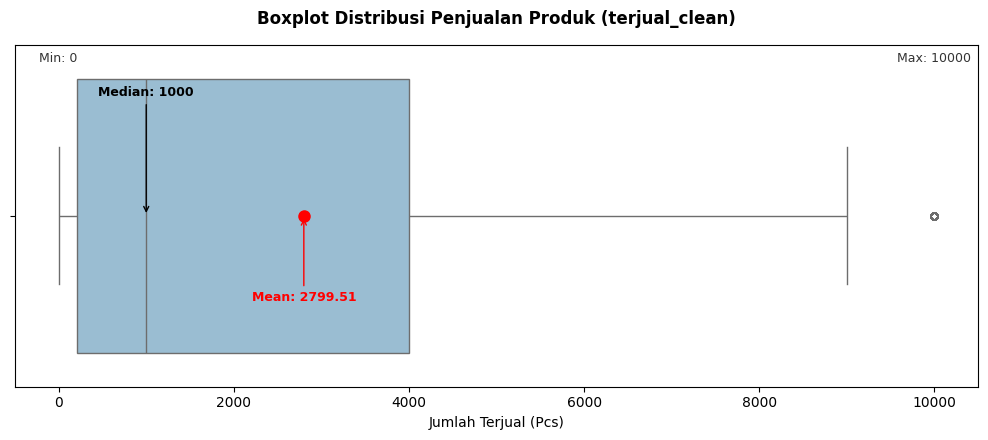

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung statistik
mean = df["terjual_clean"].mean()
median = df["terjual_clean"].median()
modus = df["terjual_clean"].mode()[0]
min_val = df["terjual_clean"].min()
max_val = df["terjual_clean"].max()

plt.figure(figsize=(10, 4.5))

# Plot Boxplot
ax = sns.boxplot(
    data=df,
    x="terjual_clean",
    color="#91bfdb",
    fliersize=5,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "red",
        "markersize": "8",
    },
)

# Keterangan Angka di Grafik (Annotations)
# 1. Teks Mean
plt.annotate(
    f"Mean: {mean:.2f}",
    xy=(mean, 0),
    xytext=(mean, -0.25),
    ha="center",
    fontsize=9,
    fontweight="bold",
    color="red",
    arrowprops=dict(arrowstyle="->", color="red", lw=1),
)

# 2. Teks Median
plt.annotate(
    f"Median: {median:.0f}",
    xy=(median, 0),
    xytext=(median, 0.35),
    ha="center",
    fontsize=9,
    fontweight="bold",
    color="black",
    arrowprops=dict(arrowstyle="->", color="black", lw=1),
)

# 3. Teks Min & Max
plt.text(
    min_val,
    0.45,
    f"Min: {min_val:.0f}",
    ha="center",
    fontsize=9,
    color="#333333",
)
plt.text(
    max_val,
    0.45,
    f"Max: {max_val:.0f}",
    ha="center",
    fontsize=9,
    color="#333333",
)

# Setting Judul & Sumbu
plt.title(
    "Boxplot Distribusi Penjualan Produk (terjual_clean)",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Jumlah Terjual (Pcs)", fontsize=10)
plt.ylim(-0.5, 0.5)  # Memberi ruang untuk teks anotasi

plt.tight_layout()
plt.show()

Ditemui bahwa mean > dari median

kemungkinan imbalance dengan pola skewed positif selanjutnya, kita buktikan dengan visualisasi menggunakan histogram

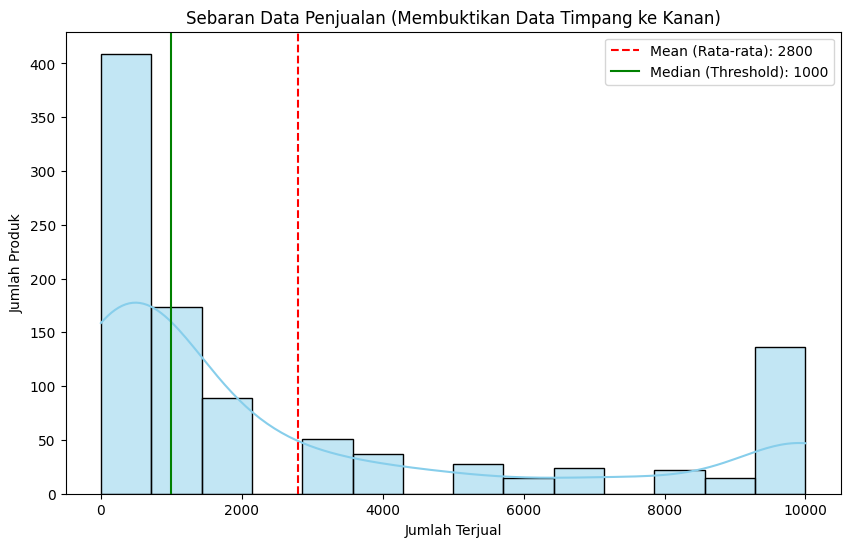

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Plot distribusi
sns.histplot(df['terjual_clean'], kde=True, color='skyblue')

# Tambahkan garis vertikal untuk Rata-rata vs Median
plt.axvline(df['terjual_clean'].mean(), color='red', linestyle='--', label=f"Mean (Rata-rata): {df['terjual_clean'].mean():.0f}")
plt.axvline(df['terjual_clean'].median(), color='green', linestyle='-', label=f"Median (Threshold): {df['terjual_clean'].median():.0f}")

plt.title('Sebaran Data Penjualan (Membuktikan Data Timpang ke Kanan)')
plt.xlabel('Jumlah Terjual')
plt.ylabel('Jumlah Produk')
plt.legend()
plt.show()

DARI SINI DIPUTUSKAN THRESHOLD PALING ADIL ADALAH MEMAKAI MEDIAN = 1000

LABEL ENCODING

In [19]:
# --- OFFICIAL LABELING BERDASARKAN PENJUALAN ---

# 1. Menentukan Threshold sesuai kesepakatan
threshold = 1000

# 2. Membuat label target y
# 1 jika terjual_clean >= 1000 (Penjualan Lebih dari 1000)
# 0 jika terjual_clean < 1000 (Penjualan kurang dari 1000)
df['label_target'] = df['terjual_clean'].apply(lambda x: 1 if x >= threshold else 0)
y = df['label_target'].values

# 3. Cek komposisi label
lebih_dari_1000 = sum(y == 1)
kurang_dari_1000 = sum(y == 0)

print(f"Labeling Selesai (Threshold: {threshold})")
print("-" * 45)
print(f"Penjualan lebih dari 1000 pcs   : {lebih_dari_1000} produk")
print(f"Penjualan kurang dari 1000 pcs) : {kurang_dari_1000} produk")
print(f"Total Dataset                   : {len(y)} produk")

Labeling Selesai (Threshold: 1000)
---------------------------------------------
Penjualan lebih dari 1000 pcs   : 542 produk
Penjualan kurang dari 1000 pcs) : 458 produk
Total Dataset                   : 1000 produk


In [20]:
df.head()

,id,url,product_name,rating,jumlah_rating,terjual,harga,harga_coret,desc,jumlah_foto,search_tab,harga_clean,harga_coret_clean,terjual_clean,rating_clean,jumlah_rating_clean,label_target
0,00728887-6d36-422e-bdaf-2a623752b3f6,https://shopee.co.id/CASELIFY-case-iphone-x-xr...,CASELIFY case iphone x xr xs max 7 8 11 12 13 ...,5.0,20,57,Rp52.200,Rp180.000,Selamat datang di CASELIFY_OFFICIAL-\tBarang r...,10,Terbaru,52200,180000,57,5.0,20,0
1,0078893a-c53d-4df2-8601-fca47c5df01b,https://shopee.co.id/Case-Premium-Luxury-Liqui...,Case Premium Luxury Liquid Silicone Lanyard Fo...,"4,9",7,18,Rp59.000,Rp200.000,WELLCOME TO ENCT Style - BARANG READY SESUAI E...,8,Terbaru,59000,200000,18,4.9,7,0
2,00a93a24-493e-4a23-9413-aed6090f5cc6,https://shopee.co.id/BASAIN-Casing-iPhone-13-M...,BASAIN Casing iPhone 13/Mini/Pro/Max Case Prem...,4.9,85,164,Rp178.200,Rp229.000,Premium Silicone 2.0 hadir dengan tambahan Mag...,10,Terbaru,178200,229000,164,4.9,85,0
3,02f7bb99-2e8c-4589-8a92-85fa2e334eef,https://shopee.co.id/SUIRGE-Suitable-for-iPhon...,SUIRGE Suitable for iPhone 16 17/16 Pro /17 Pr...,5,18,77,Rp32.900,Rp60.000,Properti:1.100% baru2 Bahan: Terbuat dari kare...,8,Terbaru,32900,60000,77,5.0,18,0
4,0419b19d-f95b-4d68-bf73-3d2c0c4c16e2,https://shopee.co.id/CASE-RUBER-HITAM-ANTI-NOD...,CASE RUBER HITAM + ANTI NODA FOR IPHONE X XR X...,4.9,69,203,Rp49.476,Rp79.800,BACA DESKRIPSINYA DULU YUK BIAR MAKIN PAHAM SA...,8,Terbaru,49476,79800,203,4.9,69,0


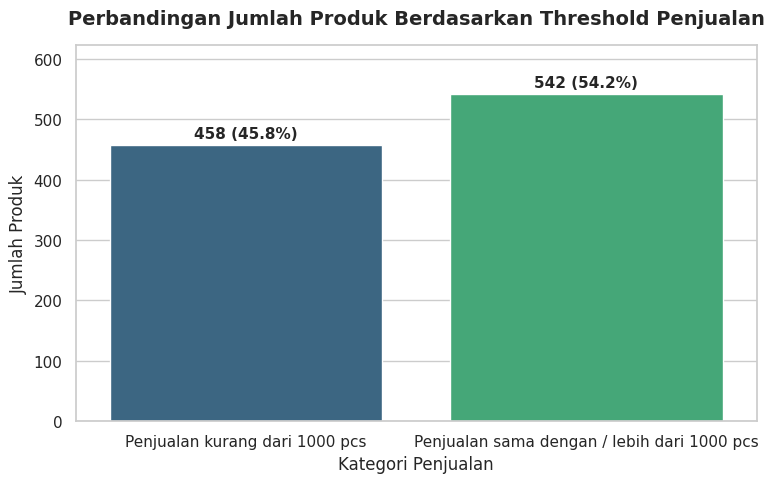

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style seaborn
sns.set_theme(style="whitegrid")

# 1. Membuat Figure
plt.figure(figsize=(8, 5))

# 2. Plotting countplot (diperbaiki agar tidak memicu warning)
ax = sns.countplot(
    data=df, x="label_target", hue="label_target", palette="viridis", legend=False
)

# 3. Kustomisasi Judul dan Label
plt.title(
    "Perbandingan Jumlah Produk Berdasarkan Threshold Penjualan",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Kategori Penjualan", fontsize=12)
plt.ylabel("Jumlah Produk", fontsize=12)

# 4. Label sumbu X
plt.xticks(
    ticks=[0, 1],
    labels=[
        "Penjualan kurang dari 1000 pcs",
        "Penjualan sama dengan / lebih dari 1000 pcs",
    ],
)

# Hitung total data
total = len(df)

# Cari nilai tertinggi untuk batas sumbu Y tanpa menggunakan fungsi max()
heights = [p.get_height() for p in ax.patches]
max_height = sorted(heights)[-1] if heights else 0

# 5. Menambahkan label angka dan persentase di atas setiap bar
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    # Format teks: Jumlah (Persentase%)
    ax.annotate(
        f"{int(height)} ({percentage:.1f}%)",
        (p.get_x() + p.get_width() / 2.0, height),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
    )

# Atur batas sumbu Y agar teks persentase tidak terpotong
plt.ylim(0, max_height * 1.15)

# Tampilkan grafik
plt.tight_layout()
plt.show()

Preprocessing Teks (NLP Pipeline)

Melihat 50 Kata Terbanyak

In [22]:
from collections import Counter
import re

# 1. Gabungkan semua teks menjadi satu string besar
all_text = " ".join(df['product_name'].astype(str) + " " + df['desc'].astype(str)).lower()

# 2. Cleansing ringan (hanya sisakan huruf) untuk melihat distribusi kata asli
all_text = re.sub(r'[^a-z\s]', ' ', all_text)

# 3. Hitung frekuensi setiap kata
word_counts = Counter(all_text.split())

# 4. Tampilkan 50 kata yang paling sering muncul
print("DAFTAR 50 KATA PALING SERING MUNCUL:")
print("-" * 40)

for word, count in word_counts.most_common(50):
    print(f"{word}: {count}")

DAFTAR 50 KATA PALING SERING MUNCUL:
----------------------------------------
iphone: 4969
a: 4741
dan: 4124
pro: 3726
yang: 2803
case: 2691
untuk: 2612
dengan: 2473
di: 2091
anda: 1961
kami: 1958
casing: 1788
tidak: 1727
max: 1677
s: 1567
produk: 1566
anti: 1407
plus: 1229
jika: 1212
dari: 1166
ponsel: 1090
bahan: 999
c: 981
warna: 978
akan: 878
note: 772
samsung: 769
g: 738
tahan: 728
pengiriman: 724
x: 722
mudah: 711
magsafe: 698
y: 698
model: 694
hp: 689
barang: 680
for: 653
tinggi: 645
premium: 623
tpu: 613
kamera: 600
bisa: 599
lebih: 597
dalam: 569
perlindungan: 565
melindungi: 564
soft: 563
m: 548
xs: 545


In [23]:
# --- TAHAP 1: CASE FOLDING ---

# Kita buat kolom gabungan awal dulu sebagai referensi data kotor
df['text_original'] = df['product_name'].astype(str) + " " + df['desc'].astype(str)

# Proses Case Folding: Mengubah semua huruf menjadi kecil (lowercase)
df['step_1_folding'] = df['text_original'].str.lower()

print("--- TAHAP 1: CASE FOLDING (PENYERAGAMAN HURUF KECIL) ---")
print("-" * 60)

# Menampilkan perbandingan 3 baris pertama
for i in range(3):
    print(f"Data Ke-{i+1}")
    print(f"SEBELUM (Original) : {df['text_original'].iloc[i][:100]}...") # Potong 100 karakter saja agar rapi
    print(f"SESUDAH (Folding)  : {df['step_1_folding'].iloc[i][:100]}...")
    print("-" * 60)

--- TAHAP 1: CASE FOLDING (PENYERAGAMAN HURUF KECIL) ---
------------------------------------------------------------
Data Ke-1
SEBELUM (Original) : CASELIFY case iphone x xr xs max 7 8 11 12 13 14 15 16 pro max plus casing silikon ponsel hp softcas...
SESUDAH (Folding)  : caselify case iphone x xr xs max 7 8 11 12 13 14 15 16 pro max plus casing silikon ponsel hp softcas...
------------------------------------------------------------
Data Ke-2
SEBELUM (Original) : Case Premium Luxury Liquid Silicone Lanyard For Iphone 11 12 13 14 15 16 17 Pro Max Magnetic Magsafe...
SESUDAH (Folding)  : case premium luxury liquid silicone lanyard for iphone 11 12 13 14 15 16 17 pro max magnetic magsafe...
------------------------------------------------------------
Data Ke-3
SEBELUM (Original) : BASAIN Casing iPhone 13/Mini/Pro/Max Case Premium Soft Silicone 2.0 | Compatible MagSafe Premium Sil...
SESUDAH (Folding)  : basain casing iphone 13/mini/pro/max case premium soft silicone 2.0 | compatible mag

In [24]:
import re

# --- TAHAP 2: CLEANING / NOISE REMOVAL ---

def remove_noise(text):
    # 1. Menghapus URL/Link (http, https, www)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # 2. Menghapus karakter yang BUKAN huruf (menghapus angka, simbol, dan tanda baca)
    # Kita hanya menyisakan a-z dan spasi
    text = re.sub(r'[^a-z\s]', ' ', text)
    # 3. Menghapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Menerapkan fungsi cleaning pada hasil Tahap 1 (Case Folding)
df['step_2_cleaning'] = df['step_1_folding'].apply(remove_noise)

print("--- TAHAP 2: CLEANING (PENGHAPUSAN SIMBOL & ANGKA) ---")
print("-" * 60)

# Menampilkan perbandingan 3 baris pertama
for i in range(3):
    print(f"Data Ke-{i+1}")
    print(f"SEBELUM (Folding)  : {df['step_1_folding'].iloc[i][:100]}...")
    print(f"SESUDAH (Cleaning) : {df['step_2_cleaning'].iloc[i][:100]}...")
    print("-" * 60)

--- TAHAP 2: CLEANING (PENGHAPUSAN SIMBOL & ANGKA) ---
------------------------------------------------------------
Data Ke-1
SEBELUM (Folding)  : caselify case iphone x xr xs max 7 8 11 12 13 14 15 16 pro max plus casing silikon ponsel hp softcas...
SESUDAH (Cleaning) : caselify case iphone x xr xs max pro max plus casing silikon ponsel hp softcase hardcase casing imd ...
------------------------------------------------------------
Data Ke-2
SEBELUM (Folding)  : case premium luxury liquid silicone lanyard for iphone 11 12 13 14 15 16 17 pro max magnetic magsafe...
SESUDAH (Cleaning) : case premium luxury liquid silicone lanyard for iphone pro max magnetic magsafe strap shockproof bac...
------------------------------------------------------------
Data Ke-3
SEBELUM (Folding)  : basain casing iphone 13/mini/pro/max case premium soft silicone 2.0 | compatible magsafe premium sil...
SESUDAH (Cleaning) : basain casing iphone mini pro max case premium soft silicone compatible magsafe premiu

In [25]:
# --- TAHAP 3: TOKENIZATION (PEMECAHAN KALIMAT MENJADI KATA) ---

# Menggunakan fungsi .split() untuk memecah string menjadi list of strings
df['step_3_token'] = df['step_2_cleaning'].apply(lambda x: x.split())

print("--- TAHAP 3: TOKENIZATION (BARIS PER BARIS) ---")
print("-" * 60)

# Menampilkan perbandingan 3 baris pertama
for i in range(3):
    print(f"Data Ke-{i+1}")
    print(f"SEBELUM (Cleaning)   : {df['step_2_cleaning'].iloc[i][:100]}...")
    # Kita tunjukkan 10 token pertama agar tidak terlalu panjang di layar
    print(f"SESUDAH (Tokenized)  : {df['step_3_token'].iloc[i][:10]}")
    print(f"Tipe Data Sesudah    : {type(df['step_3_token'].iloc[i])}") # Membuktikan sudah jadi List
    print("-" * 60)

--- TAHAP 3: TOKENIZATION (BARIS PER BARIS) ---
------------------------------------------------------------
Data Ke-1
SEBELUM (Cleaning)   : caselify case iphone x xr xs max pro max plus casing silikon ponsel hp softcase hardcase casing imd ...
SESUDAH (Tokenized)  : ['caselify', 'case', 'iphone', 'x', 'xr', 'xs', 'max', 'pro', 'max', 'plus']
Tipe Data Sesudah    : <class 'list'>
------------------------------------------------------------
Data Ke-2
SEBELUM (Cleaning)   : case premium luxury liquid silicone lanyard for iphone pro max magnetic magsafe strap shockproof bac...
SESUDAH (Tokenized)  : ['case', 'premium', 'luxury', 'liquid', 'silicone', 'lanyard', 'for', 'iphone', 'pro', 'max']
Tipe Data Sesudah    : <class 'list'>
------------------------------------------------------------
Data Ke-3
SEBELUM (Cleaning)   : basain casing iphone mini pro max case premium soft silicone compatible magsafe premium silicone had...
SESUDAH (Tokenized)  : ['basain', 'casing', 'iphone', 'mini', 'pr

In [26]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# 1. Ambil stopword bawaan NLTK
stop_ind = stopwords.words('indonesian')

# 2. Tambahkan daftar kata hasil audit kamu (Audit 50 Kata)
sampah_tambahan = [
    'dan', 'yang', 'untuk', 'dengan', 'di', 'anda', 'kami', 'tidak',
    'jika', 'dari', 'akan', 'dalam', 'bisa', 'lebih', 'produk',
    'pengiriman', 'barang', 'ponsel', 'hp', 'model', 'for',
    's', 'c', 'g', 'x', 'y', 'm', 'a' # Huruf gantung dari hasil audit
]
stop_ind.extend(sampah_tambahan)

# --- TAHAP 4: STOPWORD REMOVAL (PEMBERSIHAN KATA TIDAK PENTING) ---

# Filter: Ambil kata yang bukan stopword DAN panjangnya lebih dari 2 huruf
df['step_4_stopword'] = df['step_3_token'].apply(
    lambda x: [t for t in x if t not in stop_ind and len(t) > 2]
)

print("--- TAHAP 4: STOPWORD REMOVAL (FILTERING) ---")
print("-" * 60)

# Menampilkan perbandingan 3 baris pertama
for i in range(3):
    print(f"Data Ke-{i+1}")
    print(f"SEBELUM (Tokenized) : {df['step_3_token'].iloc[i][:12]}...")
    print(f"SESUDAH (Stopword)   : {df['step_4_stopword'].iloc[i][:12]}...")
    print("-" * 60)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


--- TAHAP 4: STOPWORD REMOVAL (FILTERING) ---
------------------------------------------------------------
Data Ke-1
SEBELUM (Tokenized) : ['caselify', 'case', 'iphone', 'x', 'xr', 'xs', 'max', 'pro', 'max', 'plus', 'casing', 'silikon']...
SESUDAH (Stopword)   : ['caselify', 'case', 'iphone', 'max', 'pro', 'max', 'plus', 'casing', 'silikon', 'softcase', 'hardcase', 'casing']...
------------------------------------------------------------
Data Ke-2
SEBELUM (Tokenized) : ['case', 'premium', 'luxury', 'liquid', 'silicone', 'lanyard', 'for', 'iphone', 'pro', 'max', 'magnetic', 'magsafe']...
SESUDAH (Stopword)   : ['case', 'premium', 'luxury', 'liquid', 'silicone', 'lanyard', 'iphone', 'pro', 'max', 'magnetic', 'magsafe', 'strap']...
------------------------------------------------------------
Data Ke-3
SEBELUM (Tokenized) : ['basain', 'casing', 'iphone', 'mini', 'pro', 'max', 'case', 'premium', 'soft', 'silicone', 'compatible', 'magsafe']...
SESUDAH (Stopword)   : ['basain', 'casing', 'iph

Data Asli vs Hasil Akhir Preprocessing:

In [27]:
# 1. Menyatukan kembali list of tokens menjadi kalimat utuh (untuk keperluan display)
df['text_clean_final'] = df['step_4_stopword'].apply(lambda x: " ".join(x))

# 2. Menampilkan perbandingan Before vs After (Contoh 5 baris)
print("HASIL AKHIR PREPROCESSING TEKS (BEFORE VS AFTER)")
print("="*80)

# Kita ambil sampel 5 baris pertama
for i in range(5):
    print(f"DATA KE-{i+1}")
    print(f"ORIGINAL : {df['text_original'].iloc[i][:150]}...") # Limit 150 karakter agar tidak memenuhi layar
    print(f"CLEANED  : {df['text_clean_final'].iloc[i]}")
    print("-" * 80)

# 3. Opsional: Simpan ke DataFrame baru untuk ditaruh di Tabel Word/Laporan
tabel_bab4 = df[['text_original', 'text_clean_final']].head(10)

HASIL AKHIR PREPROCESSING TEKS (BEFORE VS AFTER)
DATA KE-1
ORIGINAL : CASELIFY case iphone x xr xs max 7 8 11 12 13 14 15 16 pro max plus casing silikon ponsel hp softcase hardcase casing imd angry white Selamat datang d...
CLEANED  : caselify case iphone max pro max plus casing silikon softcase hardcase casing imd angry white selamat caselify official ready varian stok disorder ready senin minggu orderan jam jaminan puas keluhan kendala hubungi garansi kirim ulang diterima salah rusak syarat penilaian buruk bintang tersedia variasi agry tulis utk tipe cek gambar slide compatible with iphone xriphone xsiphone maxiphone iphone plusiphone iphone proiphone pro maxiphone iphone proiphone pro maxiphone iphone proiphone pro max iphone iphone proiphone plusiphone pro maxiphone iphone proiphone plusiphone pro maxiphone iphone proiphone plusiphone pro max bahan pinggiran tpu soft dijamin anti menguning case tebal melindungi lensa camera lecetan benturan keunggulan dijamin kualitas premium diban

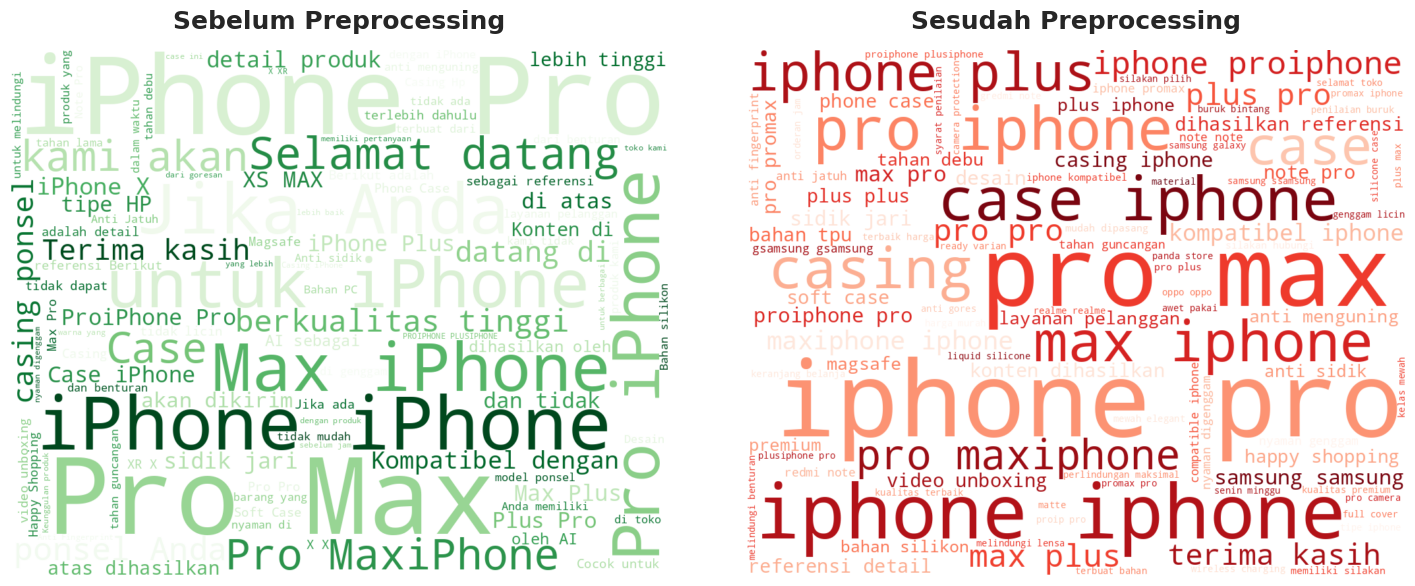

In [28]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 1. Gabungkan seluruh teks
raw_text_combined = " ".join(df['text_original'].dropna().astype(str))
clean_text_combined = " ".join(df['text_clean_final'].dropna().astype(str))

# 2. Buat WordCloud
wc_original = WordCloud(
    width=1000,
    height=800,
    background_color='white',
    colormap='Greens_r',
    max_words=100
).generate(raw_text_combined)

wc_clean = WordCloud(
    width=1000,
    height=800,
    background_color='white',
    colormap='Reds_r',
    max_words=100
).generate(clean_text_combined)

# 3. Plot gambar
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Subplot Kiri: Sebelum Preprocessing
axes[0].imshow(wc_original, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Sebelum Preprocessing', fontsize=18, fontweight='bold', pad=15)

# Subplot Kanan: Sesudah Preprocessing
axes[1].imshow(wc_clean, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Sesudah Preprocessing', fontsize=18, fontweight='bold', pad=15)

# Atur wspace jadi lebih kecil (0.12 rapat dan proporsional)
plt.subplots_adjust(wspace=0.12)

# Simpan gambar resolusi tinggi
plt.savefig('wordcloud_comparison_close.png', dpi=300, bbox_inches='tight')
plt.show()

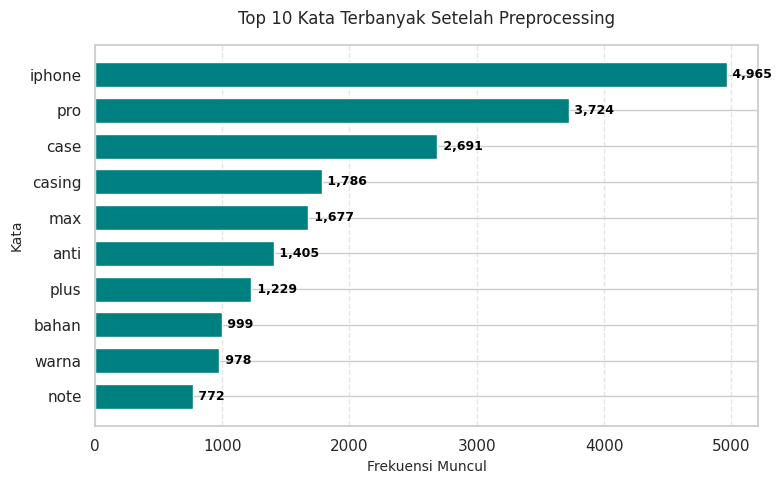

In [29]:
import matplotlib.pyplot as plt
from collections import Counter

# --- TAMBAHKAN BARIS INI UNTUK MEMPERBAIKI ERROR ---
# Mengambil semua token dari kolom hasil preprocessing (Tahap 4) ke dalam satu list
all_tokens_final = [token for sublist in df['step_4_stopword'] for token in sublist]

# 1. Ambil 10 kata terbanyak saja
most_common_10 = Counter(all_tokens_final).most_common(10)

# 2. Pisahkan kata dan jumlahnya
words, counts = zip(*most_common_10)

# 3. Visualisasi Bar Chart Horizontal dengan ukuran layar yang lebih kecil (8x5 inci)
plt.figure(figsize=(8, 5))

# Membuat batang horizontal
plt.barh(words, counts, color='teal', height=0.7)

plt.xlabel('Frekuensi Muncul', fontsize=10)
plt.ylabel('Kata', fontsize=10)
plt.title('Top 10 Kata Terbanyak Setelah Preprocessing', fontsize=12, pad=15)

plt.gca().invert_yaxis() # Kata terbanyak di urutan paling atas
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Menambahkan angka frekuensi di ujung batang
for i, v in enumerate(counts):
    plt.text(v + 10, i, f" {v:,}", color='black', va='center', fontweight='semibold', fontsize=9)

# Menyesuaikan margin agar pas saat di-screenshot
plt.tight_layout()
plt.show()

In [30]:
# 1. Gabungkan semua list token dari kolom step_4_stopword menjadi satu list besar
all_words_cleaned = [word for tokens in df['step_4_stopword'] for word in tokens]

# 2. Ambil kata yang unik saja (Vocabulary)
vocabulary = set(all_words_cleaned)

# 3. Hitung jumlahnya
jumlah_kosakata = len(vocabulary)

print(f"--- ANALISIS KOSAKATA SETELAH PREPROCESSING ---")
print("-" * 45)
print(f"Total seluruh kata yang muncul (Total Tokens) : {len(all_words_cleaned)} kata")
print(f"Jumlah kosakata unik (Vocabulary Size)        : {jumlah_kosakata} kata unik")
print("-" * 45)

--- ANALISIS KOSAKATA SETELAH PREPROCESSING ---
---------------------------------------------
Total seluruh kata yang muncul (Total Tokens) : 114859 kata
Jumlah kosakata unik (Vocabulary Size)        : 5858 kata unik
---------------------------------------------


TEXT RE-JOINING

In [31]:
# --- TAHAP 5: TEXT RE-JOINING (PENGGABUNGAN KEMBALI) ---

# Menggabungkan kembali token yang sudah bersih menjadi kalimat utuh dipisahkan spasi
df['text_clean'] = df['step_4_stopword'].apply(lambda x: " ".join(x))

print("--- TAHAP 5: TEXT RE-JOINING (SIAP UNTUK TF-IDF) ---")
print("-" * 60)

# Menampilkan perbandingan 3 baris pertama
for i in range(3):
    print(f"Data Ke-{i+1}")
    print(f"SEBELUM (List/Token) : {df['step_4_stopword'].iloc[i][:10]}...")
    print(f"SESUDAH (String/Siap) : {df['text_clean'].iloc[i][:100]}...")
    print("-" * 60)

--- TAHAP 5: TEXT RE-JOINING (SIAP UNTUK TF-IDF) ---
------------------------------------------------------------
Data Ke-1
SEBELUM (List/Token) : ['caselify', 'case', 'iphone', 'max', 'pro', 'max', 'plus', 'casing', 'silikon', 'softcase']...
SESUDAH (String/Siap) : caselify case iphone max pro max plus casing silikon softcase hardcase casing imd angry white selama...
------------------------------------------------------------
Data Ke-2
SEBELUM (List/Token) : ['case', 'premium', 'luxury', 'liquid', 'silicone', 'lanyard', 'iphone', 'pro', 'max', 'magnetic']...
SESUDAH (String/Siap) : case premium luxury liquid silicone lanyard iphone pro max magnetic magsafe strap shockproof back co...
------------------------------------------------------------
Data Ke-3
SEBELUM (List/Token) : ['basain', 'casing', 'iphone', 'mini', 'pro', 'max', 'case', 'premium', 'soft', 'silicone']...
SESUDAH (String/Siap) : basain casing iphone mini pro max case premium soft silicone compatible magsafe premium sili

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   1000 non-null   object 
 1   url                  1000 non-null   object 
 2   product_name         1000 non-null   object 
 3   rating               986 non-null    object 
 4   jumlah_rating        986 non-null    object 
 5   terjual              1000 non-null   object 
 6   harga                1000 non-null   object 
 7   harga_coret          909 non-null    object 
 8   desc                 1000 non-null   object 
 9   jumlah_foto          1000 non-null   int64  
 10  search_tab           1000 non-null   object 
 11  harga_clean          1000 non-null   int64  
 12  harga_coret_clean    1000 non-null   int64  
 13  terjual_clean        1000 non-null   int64  
 14  rating_clean         1000 non-null   float64
 15  jumlah_rating_clean  1000 non-null   in

Matriks (1000, 500) itu artinya kamu punya 1000 produk dan sekarang setiap produk dijelaskan oleh 500 fitur kata yang sudah berbentuk angka.

Tapi coba lihat di daftar kata kunci kamu: masih ada kata 'admin', 'and', dan 'are'. Kata-kata ini sebenarnya masuk kategori stopword yang terlewat. Namun, jangan khawatir! Karena kita menggunakan TF-IDF, kata-kata umum seperti itu secara otomatis akan diberi bobot yang sangat kecil oleh sistem, jadi tidak akan merusak modelmu.

Sesuai urutan di Bab 3 kamu, setelah Feature Extraction (TF-IDF), kita harus menggabungkan semua ini menjadi satu kesatuan sebelum masuk ke Data Splitting.

---

"Tapi coba lihat di daftar kata kunci kamu: masih ada kata 'admin', 'and', dan 'are'. Kata-kata ini sebenarnya masuk kategori stopword yang terlewat. Namun, jangan khawatir! Karena kita menggunakan TF-IDF, kata-kata umum seperti itu secara otomatis akan diberi bobot yang sangat kecil oleh sistem, jadi tidak akan merusak modelmu."


ini kenapa bisa terjadi? knp kamu ga memutuskan untuk membuangnya saja?

----
Jawab:


Ada dua alasan utama kenapa saya tidak langsung menyuruhmu menghapusnya secara manual dan memilih membiarkan TF-IDF yang bekerja:1. Cara Kerja Algoritma TF-IDF (Term Frequency - Inverse Document Frequency)Secara matematis, TF-IDF dirancang untuk menghukum kata-kata yang terlalu umum.TF (Term Frequency): Seberapa sering kata muncul di satu produk.IDF (Inverse Document Frequency): Seberapa langka kata itu di seluruh dataset (1000 produk).Jika kata seperti 'and' atau 'admin' muncul di hampir semua dari 1000 produk kamu, maka nilai IDF-nya akan mendekati nol.$$TF-IDF = TF \times IDF$$Karena dikalikan dengan angka yang mendekati nol, bobot akhirnya akan sangat kecil. Jadi, meskipun kata itu "ada", dia tidak akan dianggap penting oleh model Gradient Boosting saat menentukan apakah produk itu laris atau tidak.2. Menghindari "Over-Cleaning" (Pembersihan Berlebih)Dalam data teks, kita harus hati-hati agar tidak terlalu banyak menghapus kata secara manual. Kenapa?Subjektivitas: Jika kita terus-menerus menghapus kata satu per satu secara manual (seperti 'admin', 'and', 'are', 'is', 'the'), prosesnya tidak akan pernah selesai. Dosen penguji bisa bertanya: "Kenapa 'admin' dihapus tapi 'chat' tidak? Apa standarnya?"Kehilangan Konteks: Terkadang kata yang kita anggap "sampah" bisa jadi fitur unik. Misalnya, mungkin saja produk yang mencantumkan kata "admin" (misal: "Hubungi admin untuk grosir") punya pola penjualan yang berbeda. Dengan TF-IDF, kita menyerahkan penilaian "penting atau tidak" kepada statistik data, bukan kepada perasaan kita.


In [32]:
  #TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

# Inisialisasi mesin TF-IDF
tfidf = TfidfVectorizer(max_features=1500)

# Menghitung bobot untuk semua data (df['text_clean']
X_tfidf_matrix = tfidf.fit_transform(df['text_clean'])

# Simpan daftar kata kunci yang ditemukan mesin
nama_fitur = tfidf.get_feature_names_out()

TABEL 10 KATA DENGAN BOBOT TF-IDF TERTINGGI
---------------------------------------------
   Kata  Skor_Bobot
 iphone  146.187437
    pro  107.378336
   case   84.143247
    max   66.720679
 casing   64.472109
   anti   58.873482
   plus   49.409554
magsafe   47.499211
  warna   46.218345
  tahan   39.290071


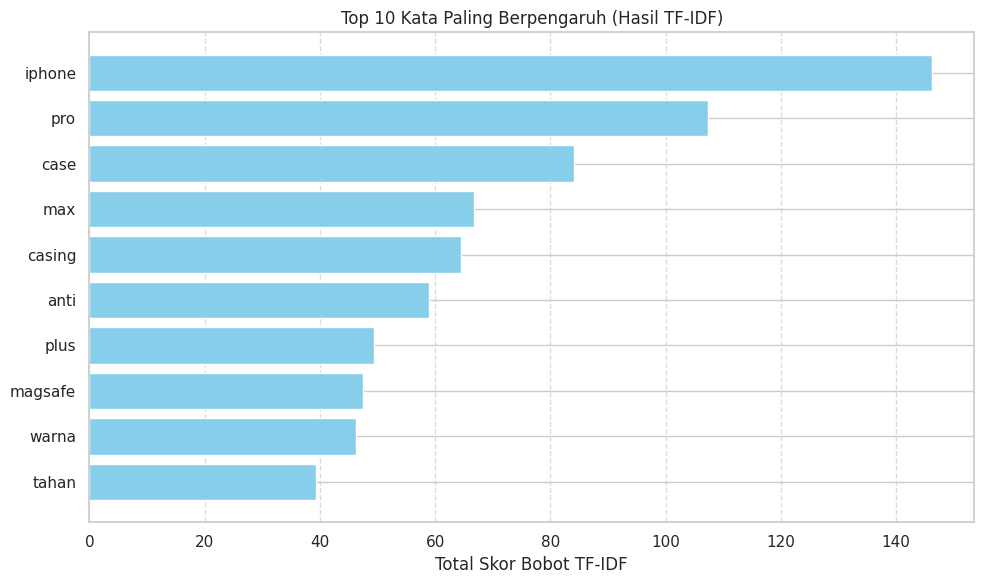

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Pastikan kolom data sudah berupa string (bukan list)
# Jika df['text_clean'] kamu masih berbentuk list, jalankan baris ini:
# df['text_clean'] = df['step_4_stopword'].apply(lambda x: " ".join(x))

# 2. Proses TF-IDF (Sesuai kodemu)
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=500)
X_tfidf_matrix = tfidf.fit_transform(df['text_clean'])
nama_fitur = tfidf.get_feature_names_out()

# 3. Menghitung total skor TF-IDF untuk setiap kata di seluruh dataset
# Kita jumlahkan kolom demi kolom (axis=0)
total_skor = X_tfidf_matrix.sum(axis=0).A1

# 4. Buat DataFrame untuk memudahkan pengurutan
df_tfidf_ranking = pd.DataFrame({
    'Kata': nama_fitur,
    'Skor_Bobot': total_skor
})

# 5. Ambil 10 besar
top_10_tfidf = df_tfidf_ranking.sort_values(by='Skor_Bobot', ascending=False).head(10)

# 6. TAMPILKAN TABEL
print("TABEL 10 KATA DENGAN BOBOT TF-IDF TERTINGGI")
print("-" * 45)
print(top_10_tfidf.to_string(index=False))

# 7. TAMPILKAN GRAFIK (Agar lebih bagus untuk Bab 4)
plt.figure(figsize=(10, 6))
plt.barh(top_10_tfidf['Kata'], top_10_tfidf['Skor_Bobot'], color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel('Total Skor Bobot TF-IDF')
plt.title('Top 10 Kata Paling Berpengaruh (Hasil TF-IDF)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

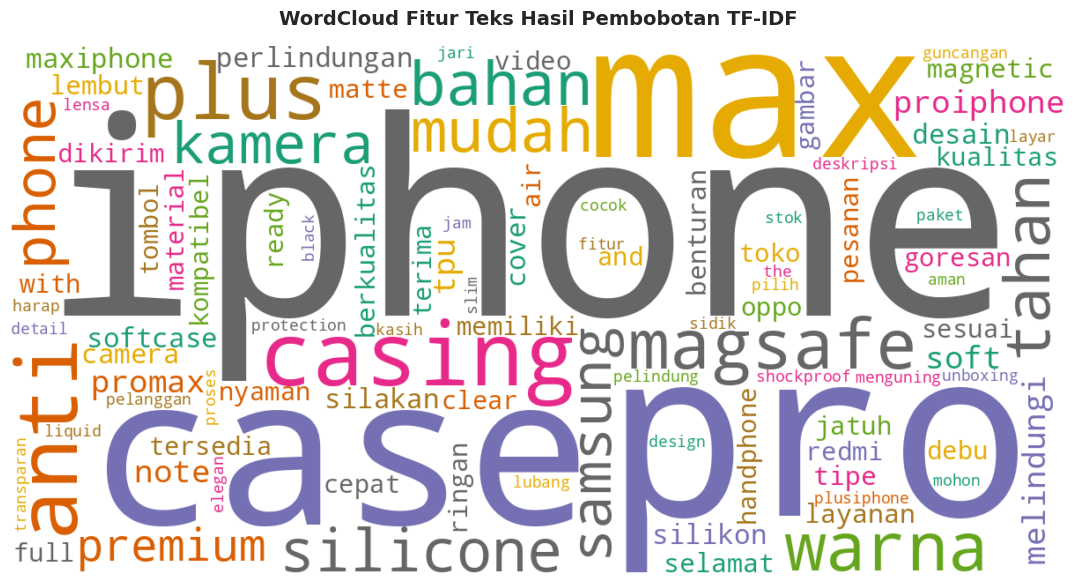

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Ekstraksi TF-IDF
tfidf = TfidfVectorizer(max_features=500)
X_tfidf_matrix = tfidf.fit_transform(df['text_clean'])
nama_fitur = tfidf.get_feature_names_out()
total_skor = X_tfidf_matrix.sum(axis=0).A1

# 2. Buat dictionary pasangan {kata: skor_tfidf}
frekuensi_kata = dict(zip(nama_fitur, total_skor))

# 3. Inisialisasi WordCloud PERBAIKAN
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='Dark2',       # Menggunakan warna kontras tinggi agar kata besar tidak samar/putat
    collocations=False,     # PENTING: Mencegah WordCloud menggabungkan/mengeliminasi kata seperti 'pro', 'max', 'case'
    prefer_horizontal=0.85, # 85% kata ditulis mendatar agar lebih mudah dibaca
    max_words=100
).generate_from_frequencies(frekuensi_kata)

# 4. Tampilkan Visualisasi
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Fitur Teks Hasil Pembobotan TF-IDF', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()

# Simpan gambar kualitas tinggi
plt.savefig('wordcloud_tfidf_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

FEATURE ENGINEERING

In [35]:
# --- LANGKAH #1: FEATURE ENGINEERING (Menciptakan Fitur Strategis) ---

df['skor_reputasi'] = df['rating_clean'] * df['jumlah_rating_clean']
df['persen_diskon'] = ((df['harga_coret_clean'] - df['harga_clean']) / df['harga_coret_clean'] * 100)
df['persen_diskon'] = df['persen_diskon'].fillna(0)
df['panjang_nama'] = df['product_name'].apply(lambda x: len(str(x)))
df['panjang_deskripsi'] = df['desc'].apply(lambda x: len(str(x)))

print("-" * 50)
print("5 data fitur baru:")
display(df[['rating_clean','jumlah_rating_clean','skor_reputasi', 'persen_diskon', 'panjang_nama', 'panjang_deskripsi']].head())

--------------------------------------------------
5 data fitur baru:


,rating_clean,jumlah_rating_clean,skor_reputasi,persen_diskon,panjang_nama,panjang_deskripsi
0,5.0,20,100.0,71.000000,133,1345
1,4.9,7,34.3,70.500000,128,1332
2,4.9,85,416.5,22.183406,88,1269
3,5.0,18,90.0,45.166667,118,676
4,4.9,69,338.1,38.000000,164,1506


#UJI PERTAMA - SEMUA (9 FITUR)

/tmp/ipykernel_555/3393094410.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_fi_num, x='Importance', y='Fitur', palette='Oranges_r')


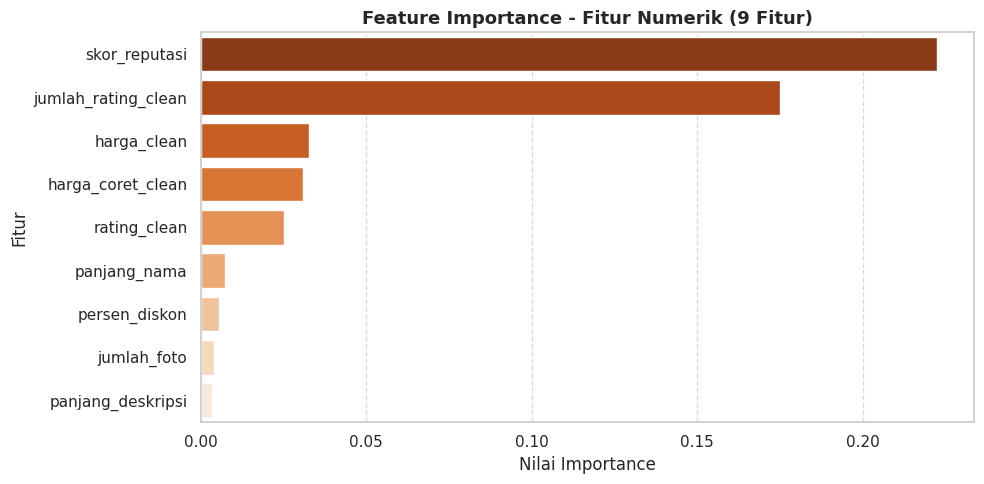


--- DETAIL FEATURE IMPORTANCE (NUMERIK) ---
              Fitur  Importance
      skor_reputasi    0.222492
jumlah_rating_clean    0.175143
        harga_clean    0.032860
  harga_coret_clean    0.030854
       rating_clean    0.025219
       panjang_nama    0.007269
      persen_diskon    0.005591
        jumlah_foto    0.003990
  panjang_deskripsi    0.003563


/tmp/ipykernel_555/3393094410.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_fi_tfidf, x='Importance', y='Fitur', palette='Blues_r')


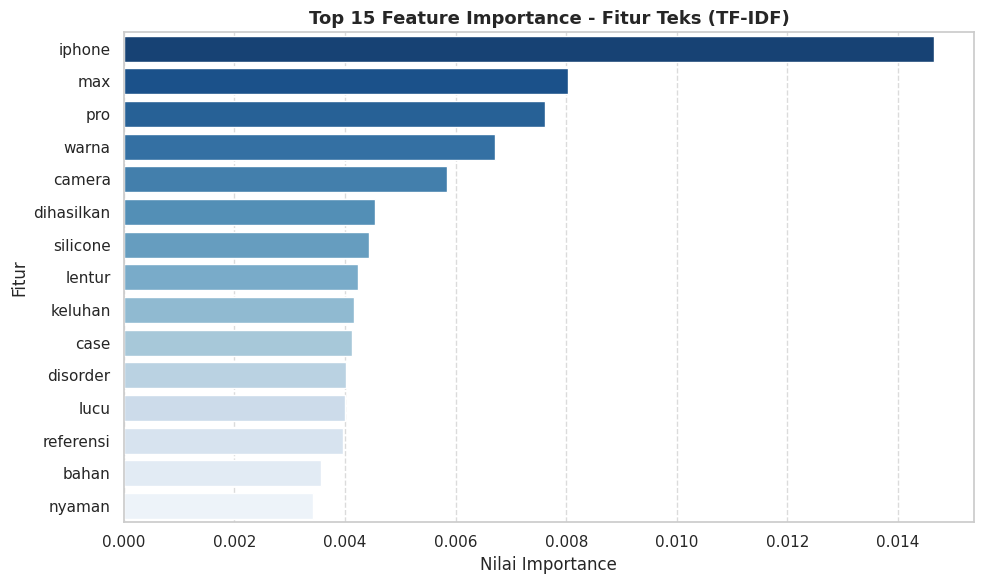


--- TOP 15 FEATURE IMPORTANCE (TEKS TF-IDF) ---
     Fitur  Importance
    iphone    0.014643
       max    0.008032
       pro    0.007614
     warna    0.006708
    camera    0.005835
dihasilkan    0.004534
  silicone    0.004437
    lentur    0.004239
   keluhan    0.004162
      case    0.004128
  disorder    0.004009
      lucu    0.004002
 referensi    0.003968
     bahan    0.003561
    nyaman    0.003428


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. DEFINISIKAN DAFTAR 9 KOLOM NUMERIK
# ==========================================
# Di sini letak 9 nama kolom numeriknya disebuttkan:
kolom_exp1 = [
    'harga_clean',
    'harga_coret_clean',
    'rating_clean',
    'jumlah_rating_clean',
    'jumlah_foto',
    'skor_reputasi',
    'persen_diskon',
    'panjang_nama',
    'panjang_deskripsi'
]

# ==========================================
# 2. AMBIL NAMA FITUR & NILAI IMPORTANCE
# ==========================================
importances = rf_model.feature_importances_

try:
    nama_fitur_tfidf = list(tfidf.get_feature_names_out())
except NameError:
    nama_fitur_tfidf = list(nama_fitur)

# Pisahkan indeks 9 fitur numerik dan fitur TF-IDF
n_num = len(kolom_exp1)  # Hasilnya 9
importances_num = importances[:n_num]
importances_tfidf = importances[n_num:]

# ==========================================
# 3. FEATURE IMPORTANCE: FITUR NUMERIK (9 FITUR)
# ==========================================
df_fi_num = pd.DataFrame({
    'Fitur': kolom_exp1,  # Menggunakan daftar 9 nama kolom di atas
    'Importance': importances_num
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_fi_num, x='Importance', y='Fitur', palette='Oranges_r')
plt.title('Feature Importance - Fitur Numerik (9 Fitur)', fontsize=13, fontweight='bold')
plt.xlabel('Nilai Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n--- DETAIL FEATURE IMPORTANCE (NUMERIK) ---")
print(df_fi_num.to_string(index=False))

# ==========================================
# 4. FEATURE IMPORTANCE: FITUR TEKS (TF-IDF)
# ==========================================
df_fi_tfidf = pd.DataFrame({
    'Fitur': nama_fitur_tfidf,
    'Importance': importances_tfidf
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_fi_tfidf, x='Importance', y='Fitur', palette='Blues_r')
plt.title('Top 15 Feature Importance - Fitur Teks (TF-IDF)', fontsize=13, fontweight='bold')
plt.xlabel('Nilai Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n--- TOP 15 FEATURE IMPORTANCE (TEKS TF-IDF) ---")
print(df_fi_tfidf.to_string(index=False))

#UJI KEDUA (7 FITUR)

✅ Total Fitur Saat Ini: 507 (7 Numerik + 500 Teks)

AKURASI RANDOM FOREST     : 81.00%
AKURASI GRADIENT BOOSTING : 77.50%

--- LAPORAN KLASIFIKASI (RANDOM FOREST) ---
              precision    recall  f1-score   support

           0       0.84      0.73      0.78        92
           1       0.79      0.88      0.83       108

    accuracy                           0.81       200
   macro avg       0.81      0.80      0.81       200
weighted avg       0.81      0.81      0.81       200



/tmp/ipykernel_555/3439295049.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_fi_num, x='Importance', y='Fitur', palette='Oranges_r')


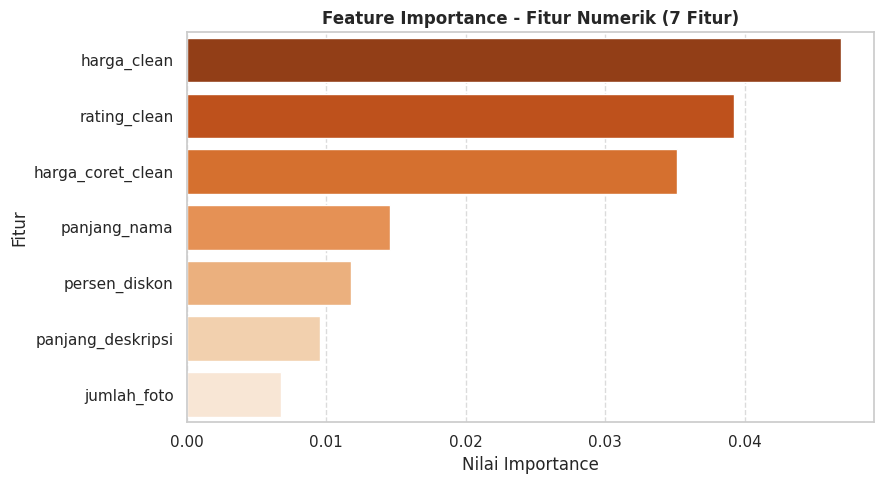


--- DETAIL FEATURE IMPORTANCE (7 NUMERIK) ---
            Fitur  Importance
      harga_clean    0.046927
     rating_clean    0.039219
harga_coret_clean    0.035155
     panjang_nama    0.014592
    persen_diskon    0.011775
panjang_deskripsi    0.009556
      jumlah_foto    0.006734


/tmp/ipykernel_555/3439295049.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_fi_tfidf, x='Importance', y='Fitur', palette='Blues_r')


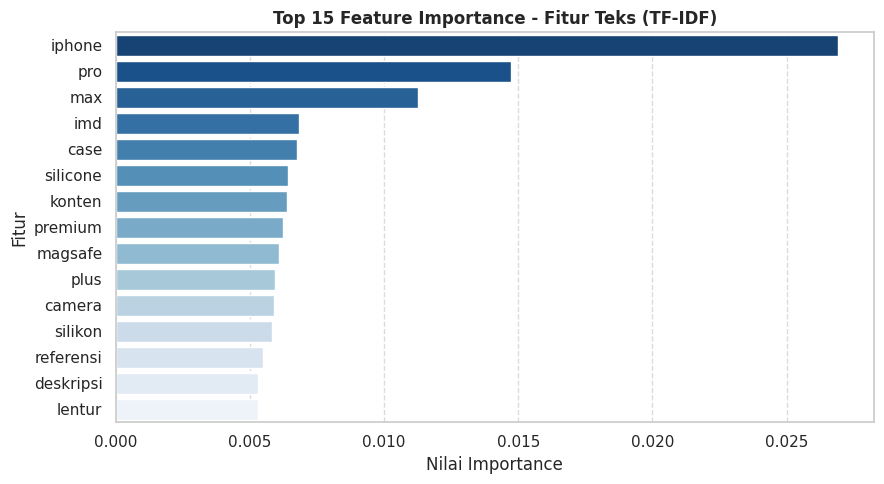

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# ==========================================
# 1. SELEKSI FITUR NUMERIK (7 FITUR)
# ==========================================
kolom_exp2 = [
    'harga_clean',
    'harga_coret_clean',
    'rating_clean',
    'jumlah_foto',
    'persen_diskon',
    'panjang_nama',
    'panjang_deskripsi'
]

# Ambil matriks 7 fitur numerik
X_num_exp2 = df[kolom_exp2].values

# Gabungkan dengan 500 fitur TF-IDF (hstack)
X_final_exp2 = hstack([X_num_exp2, X_tfidf_matrix]).tocsr()

# Ambil nama fitur TF-IDF
try:
    nama_fitur_tfidf = list(tfidf.get_feature_names_out())
except NameError:
    nama_fitur_tfidf = list(nama_fitur)

print(f"✅ Total Fitur Saat Ini: {X_final_exp2.shape[1]} ({len(kolom_exp2)} Numerik + {len(nama_fitur_tfidf)} Teks)")

# ==========================================
# 2. DATA SPLITTING (80% Train, 20% Test)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_final_exp2, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# 3. TRAINING & EVALUASI MODEL
# ==========================================
rf_model_exp2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_exp2.fit(X_train, y_train)
y_pred_rf = rf_model_exp2.predict(X_test)

gb_model_exp2 = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model_exp2.fit(X_train, y_train)
y_pred_gb = gb_model_exp2.predict(X_test)

print("\n" + "="*50)
print(f"AKURASI RANDOM FOREST     : {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print(f"AKURASI GRADIENT BOOSTING : {accuracy_score(y_test, y_pred_gb)*100:.2f}%")
print("="*50)

print("\n--- LAPORAN KLASIFIKASI (RANDOM FOREST) ---")
print(classification_report(y_test, y_pred_rf))

# ==========================================
# 4. VISUALISASI FEATURE IMPORTANCE (DIPISAH)
# ==========================================
importances = rf_model_exp2.feature_importances_

n_num = len(kolom_exp2)
importances_num = importances[:n_num]
importances_tfidf = importances[n_num:]

# --- A. FEATURE IMPORTANCE NUMERIK (7 FITUR) ---
df_fi_num = pd.DataFrame({
    'Fitur': kolom_exp2,
    'Importance': importances_num
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=df_fi_num, x='Importance', y='Fitur', palette='Oranges_r')
plt.title('Feature Importance - Fitur Numerik (7 Fitur)', fontsize=12, fontweight='bold')
plt.xlabel('Nilai Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n--- DETAIL FEATURE IMPORTANCE (7 NUMERIK) ---")
print(df_fi_num.to_string(index=False))

# --- B. FEATURE IMPORTANCE TEKS (TOP 15 TF-IDF) ---
df_fi_tfidf = pd.DataFrame({
    'Fitur': nama_fitur_tfidf,
    'Importance': importances_tfidf
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(9, 5))
sns.barplot(data=df_fi_tfidf, x='Importance', y='Fitur', palette='Blues_r')
plt.title('Top 15 Feature Importance - Fitur Teks (TF-IDF)', fontsize=12, fontweight='bold')
plt.xlabel('Nilai Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#FEATURE SELECTION

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   1000 non-null   object 
 1   url                  1000 non-null   object 
 2   product_name         1000 non-null   object 
 3   rating               986 non-null    object 
 4   jumlah_rating        986 non-null    object 
 5   terjual              1000 non-null   object 
 6   harga                1000 non-null   object 
 7   harga_coret          909 non-null    object 
 8   desc                 1000 non-null   object 
 9   jumlah_foto          1000 non-null   int64  
 10  search_tab           1000 non-null   object 
 11  harga_clean          1000 non-null   int64  
 12  harga_coret_clean    1000 non-null   int64  
 13  terjual_clean        1000 non-null   int64  
 14  rating_clean         1000 non-null   float64
 15  jumlah_rating_clean  1000 non-null   in

In [43]:
from scipy.sparse import hstack

# --- STEP 1: FEATURE SELECTION (7 FITUR NUMERIK AMAN + 500 TF-IDF) ---
# Mengeliminasi 2 fitur leakage: 'skor_reputasi' dan 'jumlah_rating_clean'
kolom_exp2 = [
    'harga_clean',
    'harga_coret_clean',
    'rating_clean',
    'jumlah_foto',
    'persen_diskon',
    'panjang_nama',
    'panjang_deskripsi'
]

# Ambil matriks 7 fitur numerik
fitur_numerik_exp2 = df[kolom_exp2].values

# Gabungkan 7 fitur numerik dengan matriks teks TF-IDF (500 fitur)
X_final_exp2 = hstack([fitur_numerik_exp2, X_tfidf_matrix]).tocsr()

print("="*60)
print(f"✅ FEATURE SELECTION BERHASIL!")
print(f"Total Fitur Matriks Akhir : {X_final_exp2.shape[1]} Fitur")
print(f"Detail Rincian             : {len(kolom_exp2)} Fitur Numerik + {X_tfidf_matrix.shape[1]} Fitur Teks (TF-IDF)")
print("="*60)

✅ FEATURE SELECTION BERHASIL!
Total Fitur Matriks Akhir : 507 Fitur
Detail Rincian             : 7 Fitur Numerik + 500 Fitur Teks (TF-IDF)


In [44]:
# =====================================================================
# --- STEP 2: DATA SPLITTING (PEMBAGIAN DATA LATIH & DATA UJI) ---
# =====================================================================
from sklearn.model_selection import train_test_split

# Pembagian data: 80% Data Latih (Training) & 20% Data Uji (Testing)
# Parameter stratify=y menjaga proporsi target label tetap seimbang di kedua subset
X_train, X_test, y_train, y_test = train_test_split(
    X_final_exp2,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("="*60)
print(f"✅ DATA SPLITTING BERHASIL!")
print(f"Jumlah Data Latih (X_train) : {X_train.shape[0]} produk ({X_train.shape[1]} fitur)")
print(f"Jumlah Data Uji (X_test)   : {X_test.shape[0]} produk ({X_test.shape[1]} fitur)")
print("="*60)

✅ DATA SPLITTING BERHASIL!
Jumlah Data Latih (X_train) : 800 produk (507 fitur)
Jumlah Data Uji (X_test)   : 200 produk (507 fitur)


In [45]:
import pandas as pd

# Pengaturan agar Pandas tidak memotong/melipat kolom ke bawah
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# ---------------------------------------------------------------------
# MENAMPILKAN TABEL DISTRIBUSI KELAS SETELAH DATA SPLITTING
# ---------------------------------------------------------------------
# Index 0 = kurang dari 1000 pcs, Index 1 = lebih dari 1000 pcs
df_split = pd.DataFrame({
    'Data Latih (80%)': [
        (y_train == 0).sum(),
        (y_train == 1).sum()
    ],
    'Data Uji (20%)': [
        (y_test == 0).sum(),
        (y_test == 1).sum()
    ]
}, index=['Penjualan kurang dari 1000 pcs', 'Penjualan lebih dari 1000 pcs'])

# Hitung Total Produk & Rasio Persentase
df_split['Total Produk'] = df_split['Data Latih (80%)'] + df_split['Data Uji (20%)']
df_split['Rasio (%)'] = (df_split['Total Produk'] / df_split['Total Produk'].sum() * 100).round(1)

# Tambahkan baris Total Akhir
df_split.loc['Total'] = df_split.sum(numeric_only=True)

print("\n" + "="*70)
print("--- TABEL DISTRIBUSI KELAS TARGET (STRATIFIED SPLITTING) ---")
print("="*70)
print(df_split)


--- TABEL DISTRIBUSI KELAS TARGET (STRATIFIED SPLITTING) ---
                                Data Latih (80%)  Data Uji (20%)  Total Produk  Rasio (%)
Penjualan kurang dari 1000 pcs             366.0            92.0         458.0       45.8
Penjualan lebih dari 1000 pcs              434.0           108.0         542.0       54.2
Total                                      800.0           200.0        1000.0      100.0


In [46]:
# =====================================================================
# --- STEP 3: OVERSAMPLING DATA TRAINING (MENGATASI DATA IMBALANCE) ---
# =====================================================================
# Aturan Emas: Oversampling dilakukan SETELAH splitting dan HANYA pada data Latih (Train)

from imblearn.over_sampling import SMOTE
import numpy as np

# Dictionary pemetaan label numerik ke teks resmi
label_map = {
    0: "Penjualan kurang dari 1000 pcs",
    1: "Penjualan lebih dari 1000 pcs"
}

print("=" * 60)
print("PROSES PENYEIMBANGAN DATA (OVERSAMPLING) DENGAN SMOTE")
print("=" * 60)

# 1. Tampilkan kondisi distribusi kelas pada data latih SEBELUM SMOTE
kelas_latih_asli = np.bincount(y_train)
print(f"Distribusi Kelas Data Latih SEBELUM SMOTE:")
print(f"  - {label_map[0]} (Kelas 0) : {kelas_latih_asli[0]} produk")
print(f"  - {label_map[1]} (Kelas 1) : {kelas_latih_asli[1]} produk")
print("-" * 60)

# 2. Inisialisasi Metode SMOTE
smote = SMOTE(random_state=42)

# 3. Eksekusi SMOTE HANYA pada data latih (X_train dan y_train)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. Tampilkan kondisi distribusi kelas pada data latih SESUDAH SMOTE
kelas_latih_baru = np.bincount(y_train_res)
print(f"Distribusi Kelas Data Latih SESUDAH SMOTE:")
print(f"  - {label_map[0]} (Kelas 0) : {kelas_latih_baru[0]} produk")
print(f"  - {label_map[1]} (Kelas 1) : {kelas_latih_baru[1]} produk")
print("-" * 60)
print(f"Ukuran X_train Asli    : {X_train.shape}")
print(f"Ukuran X_train Resampled: {X_train_res.shape}")
print("✅ Proses SMOTE Selesai! Data training sudah seimbang dan siap masuk ke Model Training.")
print("=" * 60)

PROSES PENYEIMBANGAN DATA (OVERSAMPLING) DENGAN SMOTE
Distribusi Kelas Data Latih SEBELUM SMOTE:
  - Penjualan kurang dari 1000 pcs (Kelas 0) : 366 produk
  - Penjualan lebih dari 1000 pcs (Kelas 1) : 434 produk
------------------------------------------------------------
Distribusi Kelas Data Latih SESUDAH SMOTE:
  - Penjualan kurang dari 1000 pcs (Kelas 0) : 434 produk
  - Penjualan lebih dari 1000 pcs (Kelas 1) : 434 produk
------------------------------------------------------------
Ukuran X_train Asli    : (800, 507)
Ukuran X_train Resampled: (868, 507)
✅ Proses SMOTE Selesai! Data training sudah seimbang dan siap masuk ke Model Training.


In [47]:
import pandas as pd

# Pengaturan agar Pandas tidak memotong/melipat tampilan ke bawah
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# ---------------------------------------------------------------------
# TABEL KOMPOSISI DATA LATIH SEBELUM DAN SESUDAH SMOTE
# ---------------------------------------------------------------------
df_smote = pd.DataFrame({
    'Sebelum SMOTE': [
        (y_train == 0).sum(),
        (y_train == 1).sum()
    ],
    'Sesudah SMOTE': [
        (y_train_res == 0).sum(),
        (y_train_res == 1).sum()
    ]
}, index=['Penjualan kurang dari 1000 pcs', 'Penjualan lebih dari 1000 pcs'])

# Hitung Penambahan Data Sintetis
df_smote['Penambahan Data'] = df_smote['Sesudah SMOTE'] - df_smote['Sebelum SMOTE']

# Tambahkan Baris Total Data Latih
df_smote.loc['Total Data Latih'] = df_smote.sum()

print("\n" + "="*70)
print("--- TABEL KOMPOSISI DATA LATIH (OVERSAMPLING SMOTE) ---")
print("="*70)
print(df_smote)


--- TABEL KOMPOSISI DATA LATIH (OVERSAMPLING SMOTE) ---
                                Sebelum SMOTE  Sesudah SMOTE  Penambahan Data
Penjualan kurang dari 1000 pcs            366            434               68
Penjualan lebih dari 1000 pcs             434            434                0
Total Data Latih                          800            868               68


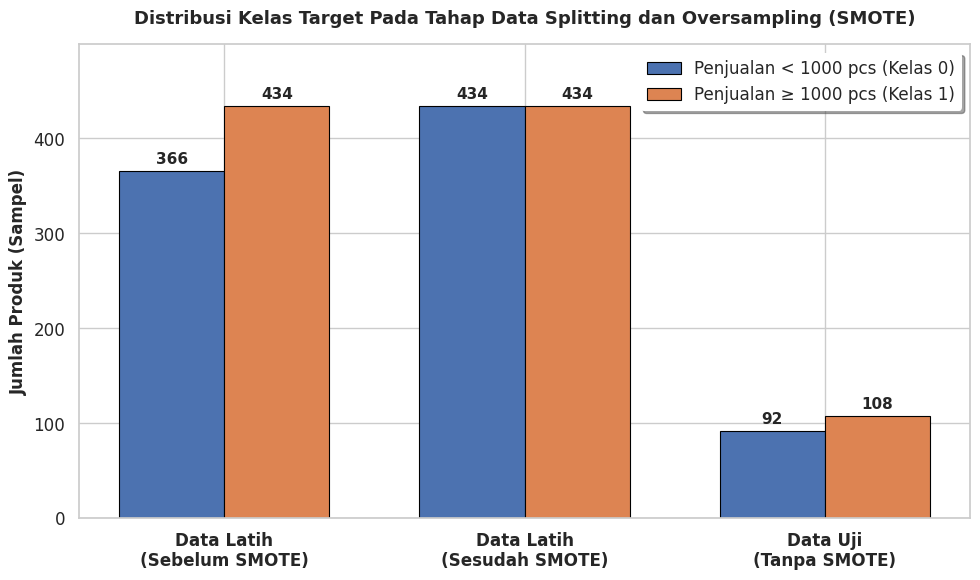

✅ Visualisasi berhasil dibuat dan disimpan sebagai 'Gambar_Distribusi_Splitting_dan_SMOTE.png'


In [50]:
import builtins  # Untuk memanggil fungsi max asli dari Python
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set style tampilan gambar agar rapi dan profesional untuk laporan ilmiah
sns.set_theme(style="whitegrid", font_scale=1.1)

# 1. Menyiapkan Data Ringkasan dari variabel yang sudah ada
categories = [
    "Data Latih\n(Sebelum SMOTE)",
    "Data Latih\n(Sesudah SMOTE)",
    "Data Uji\n(Tanpa SMOTE)",
]

# Menggunakan np.sum agar aman dan kompatibel dengan seluruh tipe array/series
kelas_0 = [
    int(np.sum(np.array(y_train) == 0)),
    int(np.sum(np.array(y_train_res) == 0)),
    int(np.sum(np.array(y_test) == 0)),
]

kelas_1 = [
    int(np.sum(np.array(y_train) == 1)),
    int(np.sum(np.array(y_train_res) == 1)),
    int(np.sum(np.array(y_test) == 1)),
]

x = np.arange(len(categories))  # Lokasi label sumbu X
width = 0.35  # Lebar batang grafik

# 2. Membuat Plot Visualisasi
fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(
    x - width / 2,
    kelas_0,
    width,
    label="Penjualan < 1000 pcs (Kelas 0)",
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.8,
)
rects2 = ax.bar(
    x + width / 2,
    kelas_1,
    width,
    label="Penjualan ≥ 1000 pcs (Kelas 1)",
    color="#DD8452",
    edgecolor="black",
    linewidth=0.8,
)

# 3. Kustomisasi Judul, Label, dan Format
ax.set_ylabel("Jumlah Produk (Sampel)", fontsize=12, fontweight="bold")
ax.set_title(
    "Distribusi Kelas Target Pada Tahap Data Splitting dan Oversampling (SMOTE)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontweight="bold")
ax.legend(
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="none",
    shadow=True,
)

# Atur batas sumbu Y otomatis menggunakan builtins.max agar tidak terbentur variabel bertabrakan
max_val = builtins.max(builtins.max(kelas_0), builtins.max(kelas_1))
ax.set_ylim(0, max_val * 1.15)


# 4. Menambahkan Angka Konkret di Atas Setiap Batang
def autolabel(rects):
  for rect in rects:
    height = rect.get_height()
    ax.annotate(
        f"{height}",
        xy=(rect.get_x() + rect.get_width() / 2, height),
        xytext=(0, 3),  # offset vertikal 3pt
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )


autolabel(rects1)
autolabel(rects2)

plt.tight_layout()

# 5. Menyimpan Gambar untuk Bab IV
plt.savefig(
    "Gambar_Distribusi_Splitting_dan_SMOTE.png", dpi=300, bbox_inches="tight"
)
plt.show()

print(
    "✅ Visualisasi berhasil dibuat dan disimpan sebagai 'Gambar_Distribusi_Splitting_dan_SMOTE.png'"
)

#HYPERPARAMETER TUNING

In [51]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

print("=" * 60)
print("PROSES HYPERPARAMETER TUNING MENGGUNAKAN RANDOMIZEDSEARCHCV")
print("=" * 60)

# 1. Definisi Ruang Parameter & Inisialisasi Tuning Gradient Boosting
gb_param_dist = {
    'n_estimators': [300, 400, 500],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 0.9],
    'max_features': ['sqrt', None]
}

random_search_gb = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=gb_param_dist,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# 2. Definisi Ruang Parameter & Inisialisasi Tuning Random Forest
rf_param_dist = {
    'n_estimators': [200, 300, 400],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# 3. Eksekusi Tuning pada Data Latih Hasil SMOTE
print("\n[1/2] Menjalankan Hyperparameter Tuning Gradient Boosting...")
random_search_gb.fit(X_train_res, y_train_res)

print("\n[2/2] Menjalankan Hyperparameter Tuning Random Forest...")
random_search_rf.fit(X_train_res, y_train_res)

print("\n" + "=" * 60)
print("✅ HYPERPARAMETER TUNING SELESAI DIEKSEKUSI!")
print("=" * 60)

PROSES HYPERPARAMETER TUNING MENGGUNAKAN RANDOMIZEDSEARCHCV

[1/2] Menjalankan Hyperparameter Tuning Gradient Boosting...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

[2/2] Menjalankan Hyperparameter Tuning Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ HYPERPARAMETER TUNING SELESAI DIEKSEKUSI!


#MODEL TRAINING

In [52]:
# =====================================================================
# --- STEP 4 (LANJUTAN): MENAMPILKAN BEST PARAMETERS & BEST MODEL ---
# =====================================================================

print("=" * 60)
print("HASIL HYPERPARAMETER TUNING & MODEL TERBAIK")
print("=" * 60)

# Simpan dan tampilkan model Gradient Boosting terbaik
model_gb_final = random_search_gb.best_estimator_
print(f"✅ Parameter GB Terbaik : {random_search_gb.best_params_}")
print(f"   Skor Akurasi Validation : {random_search_gb.best_score_*100:.2f}%")
print("-" * 60)

# Simpan dan tampilkan model Random Forest terbaik
model_rf_final = random_search_rf.best_estimator_
print(f"✅ Parameter RF Terbaik : {random_search_rf.best_params_}")
print(f"   Skor Akurasi Validation : {random_search_rf.best_score_*100:.2f}%")
print("=" * 60)

HASIL HYPERPARAMETER TUNING & MODEL TERBAIK
✅ Parameter GB Terbaik : {'subsample': 0.9, 'n_estimators': 300, 'max_features': None, 'max_depth': 8, 'learning_rate': 0.05}
   Skor Akurasi Validation : 80.99%
------------------------------------------------------------
✅ Parameter RF Terbaik : {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}
   Skor Akurasi Validation : 79.84%


#MODEL TESTING

In [53]:
# =====================================================================
# --- STEP 5: MODEL TESTING (PREDIKSI PADA DATA UJI / X_TEST) ---
# =====================================================================

print("=" * 60)
print("PROSES MODEL TESTING (PENGUJIAN PADA DATA TEST)")
print("=" * 60)

# 1. Prediksi Menggunakan Model Gradient Boosting Final
y_pred_gb = model_gb_final.predict(X_test)

# 2. Prediksi Menggunakan Model Random Forest Final
y_pred_rf = model_rf_final.predict(X_test)

print("✅ Model Testing Berhasil!")
print(f"Jumlah sampel data uji yang diprediksi : {X_test.shape[0]} produk")
print(f"Prediksi Gradient Boosting (5 teratas)  : {y_pred_gb[:5]}")
print(f"Prediksi Random Forest (5 teratas)     : {y_pred_rf[:5]}")
print("=" * 60)

PROSES MODEL TESTING (PENGUJIAN PADA DATA TEST)
✅ Model Testing Berhasil!
Jumlah sampel data uji yang diprediksi : 200 produk
Prediksi Gradient Boosting (5 teratas)  : [1 0 0 0 1]
Prediksi Random Forest (5 teratas)     : [1 0 1 0 1]


#MODEL EVALUATION

In [58]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# =====================================================================
# --- STEP 6: MODEL EVALUATION (CLASSIFICATION REPORT & ROC-AUC SCORE) ---
# =====================================================================

label_names = ['Penjualan < 1000 pcs', 'Penjualan ≥ 1000 pcs']

# Hitung probabilitas prediksi kelas positif (kelas 1)
y_prob_gb = model_gb_final.predict_proba(X_test)[:, 1]
y_prob_rf = model_rf_final.predict_proba(X_test)[:, 1]

# Hitung Skor ROC-AUC
auc_gb = roc_auc_score(y_test, y_prob_gb)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("=" * 70)
print("              EVALUASI MODEL 1: GRADIENT BOOSTING")
print("=" * 70)
print(classification_report(y_test, y_pred_gb, target_names=label_names, digits=4))
print(f"Akurasi Keseluruhan (GB) : {accuracy_score(y_test, y_pred_gb)*100:.2f}%")
print(f"Skor ROC-AUC (GB)        : {auc_gb:.4f} (atau {auc_gb*100:.2f}%)")

print("\n" + "=" * 70)
print("                EVALUASI MODEL 2: RANDOM FOREST")
print("=" * 70)
print(classification_report(y_test, y_pred_rf, target_names=label_names, digits=4))
print(f"Akurasi Keseluruhan (RF) : {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print(f"Skor ROC-AUC (RF)        : {auc_rf:.4f} (atau {auc_rf*100:.2f}%)")
print("=" * 70)

              EVALUASI MODEL 1: GRADIENT BOOSTING
                      precision    recall  f1-score   support

Penjualan < 1000 pcs     0.8235    0.7609    0.7910        92
Penjualan ≥ 1000 pcs     0.8087    0.8611    0.8341       108

            accuracy                         0.8150       200
           macro avg     0.8161    0.8110    0.8125       200
        weighted avg     0.8155    0.8150    0.8142       200

Akurasi Keseluruhan (GB) : 81.50%
Skor ROC-AUC (GB)        : 0.8957 (atau 89.57%)

                EVALUASI MODEL 2: RANDOM FOREST
                      precision    recall  f1-score   support

Penjualan < 1000 pcs     0.8068    0.7717    0.7889        92
Penjualan ≥ 1000 pcs     0.8125    0.8426    0.8273       108

            accuracy                         0.8100       200
           macro avg     0.8097    0.8072    0.8081       200
        weighted avg     0.8099    0.8100    0.8096       200

Akurasi Keseluruhan (RF) : 81.00%
Skor ROC-AUC (RF)        : 0.8887 (

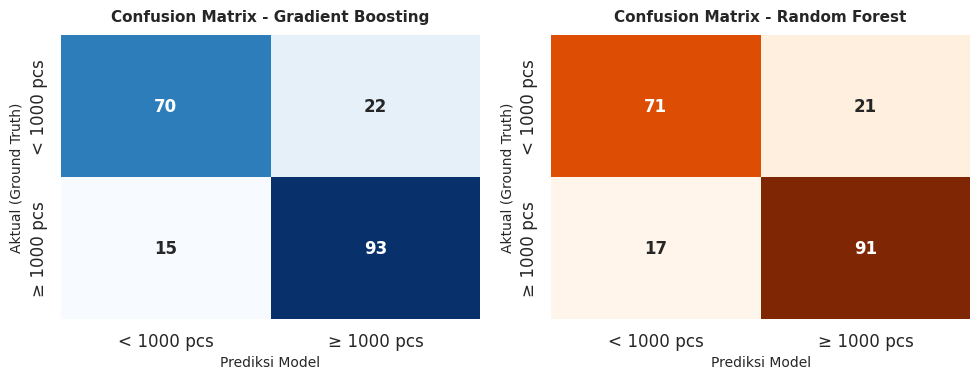

✅ Confusion Matrix berhasil dibuat dan disimpan sebagai 'Gambar_Confusion_Matrix_GB_RF.png'


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =====================================================================
# --- STEP 6 (LANJUTAN): CONFUSION MATRIX GRADIENT BOOSTING & RANDOM FOREST ---
# =====================================================================

label_names = ['< 1000 pcs', '≥ 1000 pcs']

# Hitung Confusion Matrix untuk kedua model
cm_gb = confusion_matrix(y_test, y_pred_gb)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Buat canvas gambar sejajar (1 baris, 2 kolom)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 1. Plot Confusion Matrix - Gradient Boosting
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=label_names, yticklabels=label_names, ax=axes[0],
            annot_kws={"size": 12, "weight": "bold"})
axes[0].set_title('Confusion Matrix - Gradient Boosting', fontsize=11, fontweight='bold', pad=10)
axes[0].set_xlabel('Prediksi Model', fontsize=10)
axes[0].set_ylabel('Aktual (Ground Truth)', fontsize=10)

# 2. Plot Confusion Matrix - Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=label_names, yticklabels=label_names, ax=axes[1],
            annot_kws={"size": 12, "weight": "bold"})
axes[1].set_title('Confusion Matrix - Random Forest', fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel('Prediksi Model', fontsize=10)
axes[1].set_ylabel('Aktual (Ground Truth)', fontsize=10)

plt.tight_layout()
plt.savefig("Gambar_Confusion_Matrix_GB_RF.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Confusion Matrix berhasil dibuat dan disimpan sebagai 'Gambar_Confusion_Matrix_GB_RF.png'")

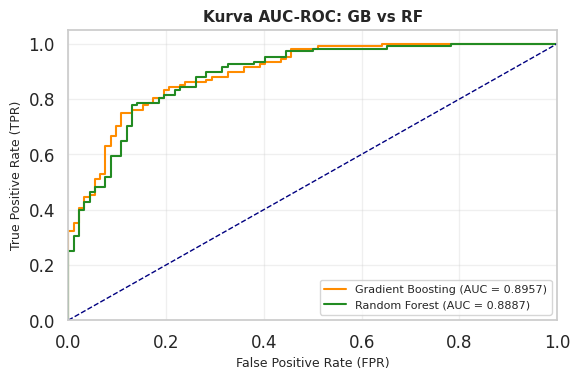

✅ Kurva ROC-AUC berhasil dibuat dan disimpan sebagai 'kurva_roc_auc.png'


In [57]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve

# =====================================================================
# --- STEP 6 (LANJUTAN): KURVA AUC-ROC (GRADIENT BOOSTING vs RANDOM FOREST) ---
# =====================================================================

# 1. Dapatkan nilai probabilitas prediksi untuk kelas positif (kelas 1)
y_prob_gb = model_gb_final.predict_proba(X_test)[:, 1]
y_prob_rf = model_rf_final.predict_proba(X_test)[:, 1]

# 2. Hitung False Positive Rate (FPR), True Positive Rate (TPR), dan AUC
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
roc_auc_gb = auc(fpr_gb, tpr_gb)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# 3. Buat grafik visualisasi Kurva ROC
plt.figure(figsize=(6, 4))

# Plot Garis GB & RF
plt.plot(
    fpr_gb,
    tpr_gb,
    color="darkorange",
    lw=1.5,
    label=f"Gradient Boosting (AUC = {roc_auc_gb:.4f})",
)
plt.plot(
    fpr_rf,
    tpr_rf,
    color="forestgreen",
    lw=1.5,
    label=f"Random Forest (AUC = {roc_auc_rf:.4f})",
)

# Garis Baseline Random Guess (0.5)
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)", fontsize=9)
plt.ylabel("True Positive Rate (TPR)", fontsize=9)
plt.title("Kurva AUC-ROC: GB vs RF", fontsize=11, fontweight="bold")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)

plt.tight_layout()

# Simpan gambar otomatis
plt.savefig("kurva_roc_auc.png", dpi=300, bbox_inches="tight")

plt.show()

print(
    "✅ Kurva ROC-AUC berhasil dibuat dan disimpan sebagai 'kurva_roc_auc.png'"
)